# ✅ Log In

## 🔐 **Authenticate to Google Cloud within Colab**

Authenticate to Google Cloud as the IAM user logged into this notebook in order to access your Google Cloud Project.

In [ ]:
from google.colab import auth

auth.authenticate_user()

MessageError: ignored

In [ ]:
import google.auth
import pandas as pd
import random

## 📈 Load Setup Data from Google Sheets

### **Read in 'World Setup Data' Google Sheet**

In [ ]:
import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

world_data = gc.open('World Setup Data')
junctions_data = gc.open('Junctions')

base_tables = ['creatures', 'resource_types', 'location_groups', 'recipes', 'players', 'collections']
secondary_tables = ['recipe_ingredient_resource_types', 'locations']

worksheets = {}
for table_name in base_tables:
    worksheets[table_name] = world_data.worksheet(table_name)

for table_name in secondary_tables:
    worksheets[table_name] = junctions_data.worksheet(table_name)

### **Create dataframes from 'Dummy Data' worksheets**

In [ ]:
def sanitize_id_column_name(table_name):
    if table_name.endswith('s'):
        table_name = table_name[:-1]
    return table_name + '_id'

def create_dataframe(table_name):
    # Load the worksheet into a pandas DataFrame
    df = pd.DataFrame(worksheets[table_name].get_all_records())

    # Sanitize column names to replace spaces with underscores
    df.columns = df.columns.str.replace(' ', '_')

    # Add unique id column
    id_column = sanitize_id_column_name(table_name)
    df = df.assign(**{id_column: range(1, len(df) + 1)})

    return df

data_frames = {}

# Iterate over all worksheets in the Google Sheet
for table_name in base_tables:
    df = create_dataframe(table_name)
    data_frames[table_name] = df

# 🌎 Create world

## World Map and Layout

In [ ]:
#
# Map Layouts and Locations
#

# Island data
ISLAND_WIDTH = 100
ISLAND_HEIGHT = 100
ISLANDS = [
    {
        "name": "Growth",
        "offset": (0, 0)
    },
    {
        "name": "Shadow",
        "offset": (-ISLAND_WIDTH, 0),
    },
    {
        "name": "Stability",
        "offset": (-ISLAND_WIDTH, -ISLAND_HEIGHT)
    },
    {
        "name": "Light",
        "offset": (0, -ISLAND_HEIGHT)
    }
]

# Plot data
PLOTS_BY_ISLAND = {
    'Stability': [
        {
            "name": "Large Garden",
            "offset": (0, 24),
            "shade_level": 75,
            "light_color": 75,
            "layout": "medium_vertical"
        },
        {
            "name": "Secret Forest",
            "offset": (12, 30),
            "layout": "extra_large_horizontal"
        },
        {
            "name": "North Fields",
            "offset": (24, 27),
            "layout": "medium_horizontal"
        },
        {
            "name": "South Fields",
            "offset": (27, 18)
        },
        {
            "name": "Small Clearing",
            "offset": (0, 15),
            "layout": "horizontal"
        },
        {
            "name": "Small Garden",
            "offset": (12, 20),
            "layout": "medium_horizontal"
        },
        {
            "name": "Large Clearing",
            "offset": (12, 0),
            "layout": "extra_large_horizontal"
        },
        {
            "name": "Community Garden",
            "offset": (15, 9)
        },
        {
            "name": "The Mines",
            "offset": (26, 6)
        }
    ],
    'Stability': [],
    'Light': [],
    'Shadow': []
}

PLOT_LAYOUTS = {
    "medium_vertical": [
        {
            "layout": "large",
            "offset": (0,0)
        },
        {
            "layout": "large",
            "offset": (0,3)
        }
    ],
    "medium_horizontal": [
        {
            "layout": "large",
            "offset": (0,0)
        },
        {
            "layout": "large",
            "offset": (3,0)
        }
    ],
    "extra_large_horizontal": [
        {
            "layout": "large",
            "offset": (0,0)
        },
        {
            "layout": "large",
            "offset": (3,0)
        },
        {
            "layout": "large",
            "offset": (6,0)
        }
    ],
    "horizontal": [
        {
            "layout": "small",
            "offset": (0,0)
        },
        {
            "layout": "medium",
            "offset": (2,0)
        },
        {
            "layout": "large",
            "offset": (6,0)
        }
    ],
    "default": [                    # 5 x 3 default
        {
            "layout": "large",
            "offset": (0,0)
        },
        {
            "layout": "medium",
            "offset": (0,3)
        }
    ]
}

# Patch data
PATCH_LAYOUTS = {
    "small": [(0,1), (1,1), (0,0), (1,0)],                                      # 2x2 patch
    "medium": [(0,1), (1,1), (2,1), (0,0), (1,0), (2,0)],                       # 3x2 patch
    "large": [(0,2), (1,2), (2,2), (0,1), (1,1), (2,1), (0,0), (1,0), (2,0)]    # 3x3 patch
}

## Simulation Parameters

In [ ]:
# World data
WEATHERS = ['Sunny', 'Rainy', 'Overcast', 'Windy']
TIMES_OF_DAY = ['AM Early', 'AM Late', 'PM Early', 'PM Late']

# Spawning Parameters
ISLAND_BASE_PROBS = {
    'Growth': {'plants': 6, 'bugs': 2, 'mushrooms': 3, 'rocks': 1},
    'Stability': {'plants': 1, 'bugs': 3, 'mushrooms': 2, 'rocks': 6},
    'Light': {'plants': 3, 'bugs': 1, 'mushrooms': 6, 'rocks': 2},
    'Shadow': {'plants': 2, 'bugs': 6, 'mushrooms': 1, 'rocks': 3},
}

ZERO_ADJUSTMENT = {'plants': 1, 'bugs': 1, 'mushrooms': 1, 'rocks': 1}

## 📓 Define logic, effects on spawn rate

 ### Spawn rate effects

 * What are the plot, patch, x, y, effects on probability of spawning a certain resource?
 * Where can I find this information for the current build?

#### Resource spawning logic
* Adjustments to base probabilities of finding any resource type at a given (x, y)

* Each x, y belongs to a patch, plot, and island

* World has day, time_of_day and weather

* The probability of a spawn event depends on:
    * island_faction_rep

* The probability of getting a certain resource type (of: 'bugs', 'plants', 'mushrooms', 'rocks') depends on:
  * island
  * time_of_day
  * weather

### Current Build
* 2 patches of collectible areas in town center
* Middle one spawns Component 1 (Green Leaf) and Component 3 (Mushroom)
* South has Component 2 (Brown Leaf) and 4 (Purple Strawberry Thing)

* Max 10 can be spawned at any time
* Takes 30 sec to respawn
* Even distribution between types w/i each plot

* How many are there?
  * Future: 4 resource types: "Bug" "Mushroom" "Plant" "Rock"

In [ ]:
#
# World-level effects
#

# Time of day effects
def time_of_day_effects(time_of_day, a):
    adjustments = a.copy()
    if time_of_day == 'AM Early':
        adjustments['bugs'] *= 2          # Bugs are more likely to appear in the morning
        adjustments['plants'] /= 2        # Plants are less likely to appear in the morning
    elif time_of_day == 'AM Late':
        adjustments['rocks'] *= 2
        adjustments['mushrooms'] /= 2
    elif time_of_day == 'PM Early':
        adjustments['plants'] *= 2
        adjustments['bugs'] /= 2
    elif time_of_day == 'PM Late':
        adjustments['mushrooms'] *= 2
        adjustments['rocks'] /= 2
    return adjustments

# Weather effects
def weather_effects(weather, a):
    adjustments = a.copy()
    if weather == 'Rainy':
        adjustments['mushrooms'] *= 2
        adjustments['rocks'] /= 2
    elif weather == 'Sunny':
        adjustments['plants'] *= 1
        adjustments['bugs'] *= 1
    elif weather == 'Windy':
        adjustments['bugs'] *= 2
    return adjustments

RESOURCES = [
    {'name': 'Dawnspore', 'faction': 'Light', 'type': 'food', 'rarity': 2, 'value': 8},
    {'name': 'Lumina Dew', 'faction': 'Light', 'type': 'sweet', 'rarity': 4, 'value': 4},
    {'name': 'Radiance Root', 'faction': 'Light', 'type': 'magic', 'rarity': 8, 'value': 2},
    {'name': 'Fungus Fiber', 'faction': 'Light', 'type': 'material', 'rarity': 16, 'value': 1},

    {'name': 'Duskworm', 'faction': 'Shadow', 'type': 'food', 'rarity': 16, 'value': 1},
    {'name': 'Shadowbug Nectar', 'faction': 'Shadow', 'type': 'sweet', 'rarity': 2, 'value': 8},
    {'name': 'Beetle Wing', 'faction': 'Shadow', 'type': 'magic', 'rarity': 4, 'value': 4},
    {'name': 'Dark Silk', 'faction': 'Shadow', 'type': 'material', 'rarity': 8, 'value': 2},

    {'name': 'Lifeseed', 'faction': 'Growth', 'type': 'food', 'rarity': 8, 'value': 2},
    {'name': "Sweetsap", 'faction': 'Growth', 'type': 'sweet', 'rarity': 16, 'value': 1},
    {'name': 'Tranquil Moss', 'faction': 'Growth', 'type': 'magic', 'rarity': 2, 'value': 8},
    {'name': 'Heartwood', 'faction': 'Growth', 'type': 'material', 'rarity': 4, 'value': 4},

    {'name': 'Stonefruit', 'faction': 'Stability', 'type': 'food', 'rarity': 4, 'value': 4},
    {'name': 'Crystallized Ginger', 'faction': 'Stability', 'type': 'sweet', 'rarity': 8, 'value': 2},
    {'name': 'Runestone Shards', 'faction': 'Stability', 'type': 'magic', 'rarity': 16, 'value': 1},
    {'name': 'Bedrock', 'faction': 'Stability', 'type': 'material', 'rarity': 2, 'value': 8}
]

ITEM_BASE_EFFECTS = {
    "potion": {
        "health_effect": 12,
        "mood_effect": 2,
        "friendship_effect": 4
    },
    "food": {
        "health_effect": 8,
        "mood_effect": 4,
        "friendship_effect": 6
    },
    "Gift": {
        "health_effect": 0,
        "mood_effect": 9,
        "friendship_effect": 9
    }
}

FACTION_EFFECT_MULTIPLIERS = {
    "gift": {
        "specific": {"in": 1, "out": 0},
        "balanced": {"in": 1, "out": 0},
        "synergistic": {"in": 1, "out": 0},
        "mixed": {"in": 1, "out": 0}
    },
    "food": {
        "specific": {"in": 1, "out": 0},
        "balanced": {"in": 1, "out": 0},
        "synergistic": {"in": 1, "out": 0},
        "mixed": {"in": 1, "out": 0}
    },
    "potion": {
        "specific": {"in": 1, "out": 0},
        "balanced": {"in": 1, "out": 0},
        "synergistic": {"in": 1, "out": 0},
        "mixed": {"in": 1, "out": 0}
    }
}

#
# Plot-level effects
#

# Shade effects
def shade_effects(shade_level, a):
    adjustments = a.copy()

    if 0 <= shade_level <= 33:          # Low shade
        adjustments['mushrooms'] *= 1.3
        adjustments['plants'] *= 2      # Plants grow best in mild shade
    elif 34 <= shade_level <= 66:  # Medium shade
        adjustments['bugs'] *= 1        # Bugs slightly prefer medium shade
    else:  # High shade
        adjustments['mushrooms'] /= 1.3   # GlowMushrooms love deep shade
        adjustments['plants'] /= 1.3      # Plants don't thrive in high shade

    return adjustments;

# Light effects (assuming light_color is a value from 0 to 100, where 100 is bluest)
def light_effects(light_color, a):
    adjustments = a.copy()

    if 0 <= light_color <= 33:  # Reddish light
        adjustments['mushrooms'] *= 1  # Slightly favorable for mushrooms
    elif 34 <= light_color <= 66:  # Neutral light
        adjustments['plants'] *= 1  # Neutral light slightly promotes plant growth
    else:  # Blue light
        adjustments['plants'] *= 1  # Blue light strongly promotes plant growth
        adjustments['bugs'] *= 1     # Bugs are less likely in blue light

    return adjustments;


#
# Patch-level effects
#

# Water effects
def water_effects(water_level, a):
    adjustments = a.copy()

    if 0 <= water_level <= 33:  # Low water level
        adjustments['rocks'] *= 1  # More likely to find rocks in dry areas
        adjustments['plants'] *= 1   # Plants suffer without much water
    elif 34 <= water_level <= 66:  # Medium water level
        adjustments['plants'] *= 1   # Plants thrive in balanced water conditions
    else:  # High water level
        adjustments['mushrooms'] *= 1  # Mushrooms thrive in wet conditions
        adjustments['plants'] *= 1    # Plants like water but not too much
        adjustments['rocks'] *= 1     # Less likely to find rocks in marshy areas

    return adjustments;


# Soil effects
def soil_effects(soil_quality, a):
    adjustments = a.copy()

    if 0 <= soil_quality <= 33:  # Low-quality soil
        adjustments['rocks'] *= 1     # More rocks found in low-quality soil
        adjustments['plants'] *= 1    # Plants don't thrive in low-quality soil
    elif 34 <= soil_quality <= 66:  # Medium-quality soil
        adjustments['plants'] *= 1    # No effect of medium-quality soil
    else:  # High-quality soil
        adjustments['plants'] *= 1    # Plants thrive in high-quality soil
        adjustments['bugs'] *= 1      # Bugs are attracted to rich soil
        adjustments['mushrooms'] *= 1  # Mushrooms grow better in rich soil

    return adjustments;

### How does crafting work (which resource combinations create which potions)?

* Where is this information?
* How many resource types, how many potions? Where can I find a list of resource types and/or potions?

In [ ]:
# Two resources combine to create an item (for now, just potion?)
# List of recipes: some combinations make a good potion, others make a bad potion (Strange Potion).

# Component combinations:
# Each faction has a potion that will be good

# Growth Potion: Component 1 and Component 2 (Two Leaves)
# Stability Potion: Component 3 and 4 (Mushroom + Strawberry)
# Shadow Potion: 1 and 4 (Leaf + Straw)
# Light Potion: 2 and 3 (Leaf + Mushroom)


# Faction: Gr, St, Li, Sh
# Resources: Bug (Li), Plant (Gr), Rock (St), Mushroom (Sh)

# Any two Resources --> Some type of Potion


# Treatment Mini-game
# Golems want stability; Trees want growth potion.

# All other combinations --> Strange Potion

# Correct Faction Potion: 100% Health; +40% to mood
# Incorrect Faction Potion (bad combination): -10% to Health and Mood

# doesn't exist yet: Neutral Potion: -10% Health; -15% mood (none exist)

import random

def get_item_blend(ingredient1, ingredient2):
    # Determine Potion Type
    item_blend = None

    balanced_combinations = [("Light", "Shadow"), ("Growth", "Stability")]
    synergistic_combinations = [("Light", "Growth"), ("Shadow", "Stability")]
    mixed_combinations = [("Light", "Stability"), ("Shadow", "Growth")]

    type1 = ingredient1["faction"]
    type2 = ingredient2["faction"]

    if (type1, type2) in balanced_combinations or (type2, type1) in balanced_combinations:
        item_blend = "Balanced"
    elif (type1, type2) in synergistic_combinations or (type2, type1) in synergistic_combinations:
        item_blend = "Synergistic"
    elif (type1, type2) in mixed_combinations or (type2, type1) in mixed_combinations:
        item_blend = "Mixed"
    elif (type1 == type2):
        item_blend = "Specific"

    return item_blend

def craft(ingredient1, ingredient2):
    item_type = get_item_type(ingredient1, ingredient2)
    potion_name_part = None

    # Determine Potion Type
    if item_type == "Balanced":
        potion_name_part = "Balanced Elixir"
    elif item_type == "Synergistic":
        potion_name_part = "Synergistic Tonic"
    elif item_type == "Mixed":
        potion_name_part = "Mixture"
    elif item_type == "Specific":
        potion_name_part = "Faction Special"

    # Construct unique potion name
    potion_name = f"{ingredient1['faction']} & {ingredient2['faction']} {potion_name_part}"

    # Calculate total quality
    total_quality = ingredient1['quality'] + ingredient2['quality']

    potion = {
        "name": potion_name,
        "type": item_type,
        "quality": total_quality,
        "ingredient1": ingredient1,
        "ingredient2": ingredient2
    }

    return potion

### What is the effect of an item on creature mood and health?

#### Currently

Gifting:
- Each faction has two likes and one dislikes
- All Golems like 3, 4 (dislike 1)
- Trees like 1, 2 (dislike 4)

- mood_effect: like --> 20% increase; dislike --> 20% decrease; neutral --> 5% increase (potions would be neutral)
- reputation: no effect yet

In [ ]:
# Function to return mood and health effects of potion on creature
def get_item_effects(item, creature_faction):
    # Determine Potion Type
    potion_type = get_potion_type(item['ingredient1'], item['ingredient2'])
    total_quality = item['quality']

    # Determine Effect based on Potion Type
    health_effect = 0
    mood_effect = 0

    if potion_type == "Balanced":
        health_effect = total_quality / 2   # Restore health based on average quality
        mood_effect = total_quality / 2     # Balance mood

    elif potion_type == "Synergistic":
        if creature_faction in [ingredient1['faction'], ingredient2['faction']]:
            health_effect = total_quality * 2  # Boost health
            mood_effect = total_quality        # Improve mood
        else:
            health_effect = -total_quality      # Decrease health
            mood_effect = -total_quality        # Worsen mood

    elif potion_type == "Mixed":
        if creature_faction in [ingredient1['faction'], ingredient2['faction']]:
            health_effect = total_quality / 2       # Slightly decrease health
            mood_effect = -total_quality            # Worsen mood
        else:
            health_effect = total_quality / 2       # Slightly increase health
            mood_effect = total_quality             # Increase mood

    return health_effect, mood_effect

### What is the effect of an item on creature relationship and/or faction rep?

In [ ]:
# Function to return relationship and faction rep effects of item on creature
def get_item_rep_effects(creature, item):
    relationship_effect = 1
    faction_rep_effect = 1

    # calculate actual effect based on some logic using creature and potion variables:
      # creature.creature_faction
      # creature.creature_color
      # creature.creature_attribute
      # creature.creature_health
      # creature.creature_mood
      # item.recipe_base_mood_effect
      # item.recipe_base_health_effect

    return {relationship_effect: relationship_effect, faction_rep_effect: faction_rep_effect}

### How does creature destination depend on creature parameters and day/time/weather etc?

In [ ]:
# day phase: 30 or 60 seconds each
# mood and health drop by 5-10% overnight

# random location over all map (screen)

# 35% chance to move to different map
# within map, wander randomly
# medical building at 40%

# Events have name of map, position within map
#

# Function returning the destination of a creature at a certain time
def get_creature_destination(creature, day, time_of_day):

    # Destinations are: islands, plot, player houses, medical building, community centers, shop, watering hole...
    destination = ''

    # adjust destination based on:
    #     creature_faction
    #     creature_color
    #     creature_attribute
    #     creature_health
    #     creature_mood
    #     day
    #     time_of_day

    return {destination: destination}

## Define classes: SpawnSquare, Patch, Plot, Island and World

In [ ]:
import random

class SpawnSquare:
    def __init__(self, parent_patch, offset):
        self.parent_patch = parent_patch
        plot = parent_patch.parent_plot
        island = plot.parent_island

        # spawn squares have x, y coords and a resource
        self.offset = offset
        self.coords = (island.offset[0] + plot.offset[0] + parent_patch.offset[0] + self.offset[0], island.offset[1] + plot.offset[1] + parent_patch.offset[1] + self.offset[1])
        self.resource = {}

    def normalize_probabilities(self, base_prob, adjustments):
        # Add adjustments
        for key, value in adjustments.items():
            base_prob[key] *= value

        # Normalize
        total = sum(base_prob.values())
        for key in base_prob:
            base_prob[key] /= total

        return base_prob

    def spawn_resource(self):
        patch = self.parent_patch
        plot = patch.parent_plot
        island = plot.parent_island
        world = island.parent_world

        time_of_day = world.time_of_day
        weather = world.weather

        # Calculate adjustments
        adjustments = ZERO_ADJUSTMENT.copy();
        adjustments = time_of_day_effects(time_of_day, adjustments)
        adjustments = weather_effects(weather, adjustments)

        # Normalize probabilities
        normalized_probs = self.normalize_probabilities(island.base_probs.copy(), adjustments)

        # Randomly select resource based on adjusted probabilities
        resources = list(normalized_probs.keys())
        probabilities = list(normalized_probs.values())
        return random.choices(resources, probabilities, k=1)[0]

class Patch:
    def __init__(self, parent_plot, patch_params):
        self.parent_plot = parent_plot

        # patches have offset_x, offset_y
        self.layout = patch_params.get("layout", "small")
        self.offset = patch_params.get("offset", (0,0))

        # patches have water_level and soil_quality
        self.water_level = patch_params.get("water_level", random.randint(0, 100))
        self.soil_quality = patch_params.get("soil_quality", random.randint(0, 100))

        # patches have spawn_squares
        self.spawn_squares = [
            SpawnSquare(self, offset) for offset in PATCH_LAYOUTS.get(self.layout, [])
        ]

class Plot:
    def __init__(self, parent_island, plot_params):
        self.parent_island = parent_island

        # plots have offset_x, offset_y
        self.name = plot_params.get("name", "Plot")
        self.offset = plot_params.get("offset", (0,0))
        self.layout = plot_params.get("layout", "default")

        # plots have shade_level and light_color
        self.shade_level = plot_params.get("shade_level", 50)
        self.light_color = plot_params.get("light_color", 50)

        # plots have patches
        self.patches = [
            Patch(self, patch) for patch in PLOT_LAYOUTS.get(self.layout, [])
        ]

class Island:
    def __init__(self, parent_world, island_data):
        self.parent_world = parent_world

        # islands have offset vector
        self.name = island_data.get("name", "Island")
        self.offset = island_data.get("offset", (0,0))
        self.base_probs = ISLAND_BASE_PROBS.get(self.name, {})

        # islands have plots
        self.plots = {
            plot["name"]: Plot(self, plot) for plot in PLOTS_BY_ISLAND.get(self.name, [])
        }

class World:
    def __init__(self, world_data):
        self.day = world_data.get("day")
        self.time_of_day = world_data.get("time_of_day")
        self.weather = world_data.get("weather")

        # Create Islands
        self.islands = {
            island["name"]: Island(self, island) for island in world_data.get("islands", [])
        }

## Define creatures

In [ ]:
DEFAULT_FRIENDSHIP_THRESHOLD = 50

class CreaturePopulation:
    def __init__(self, creatures_data):
        self.factions = {}

        for faction_name in creatures_data.keys():
            self.factions[faction_name] = Faction(faction_name, creatures_data[faction_name])

    def get_faction_stats(self, faction_name):
        return self.factions[faction_name].get_stats()

    def get_all_faction_stats(self):
        faction_stats = {}
        for faction_name in self.factions.keys():
            faction = self.factions[faction_name]
            faction_stats[faction_name] = faction.get_stats()
        return faction_stats

    def get_creatures_list(self):
        all_creatures = []
        for faction_name in self.factions.keys():
            faction = self.factions[faction_name]
            all_creatures.append(faction.get_creatures_list())
        return all_creatures

class Faction:
    def __init__(self, faction_name, faction_creatures):
        self.name = faction_name
        self.creatures = [Creature(self, creature_data) for creature_data in faction_creatures]

    def get_creatures_list(self):
        all_creatures = []
        for creature in self.creatures:
            all_creatures.append(creature.get_name())
        return all_creatures

    def is_friends(self, player_name):
        return self.player_relationship_levels[player_name] > DEFAULT_FRIENDSHIP_THRESHOLD

    def get_stats(self):
        total_mood = sum([creature.get_mood() for creature in self.creatures])
        total_health = sum([creature.get_health() for creature in self.creatures])
        total_social = sum([creature.get_social() for creature in self.creatures])

        return {
            'mood': total_mood,
            'health': total_health,
            'social': total_social
        }

class Creature:
    def __init__(self, faction, creature_data):
        self.faction = faction
        self.name = creature_data.get("name", "CreatureName")
        self.color = creature_data.get("color", "DefaultColor")
        self.attribute = creature_data.get("attribute", "DefaultAttribute")
        self.target_location = creature_data.get("location", "DefaultLocation")
        self.health = creature_data.get("health", 50)
        self.mood = creature_data.get("mood", 50)
        self.player_relationship_levels = {}
        self.friendship_threshold = creature_data.get("friendship_threshold", DEFAULT_FRIENDSHIP_THRESHOLD)

    def get_name(self):
        return self.name

    def get_health(self):
        return self.health

    def get_mood(self):
        return self.mood

    def get_social(self):
        return sum(self.player_relationship_levels.values())

    def get_stats(self):
        return {
            'mood': self.mood,
            'health': self.health,
            'social': self.get_social()
        }

    def get_num_friends(self):
        return sum(1 for value in self.player_relationship_levels.values() if value > self.friendship_threshold)

    def is_friends(self, player_name):
        return self.player_relationship_levels.get(player_name, 0) > self.friendship_threshold

In [ ]:
CREATURES = {
    "Stability": [
        {"name": "Slate", "color": "Blue", "location": "Growth"},
        {"name": "Jasper", "color": "Orange", "location": "Growth"},
        {"name": "Stone", "color": "Red", "location": "Growth"},
        {"name": "Rocky", "color": "Green", "location": "Growth"},
        {"name": "Cliff", "color": "Purple", "location": "Growth"},
        {"name": "Grant", "color": "Blue", "location": "Growth"},
        {"name": "Jasper", "color": "Orange", "location": "Growth"},
        {"name": "Stone", "color": "Red", "location": "Growth"},
        {"name": "Rocky", "color": "Green", "location": "Growth"},
        {"name": "Cliff", "color": "Purple", "location": "Growth"},
        {"name": "Slate", "color": "Blue", "location": "Growth"},
        {"name": "Jasper", "color": "Orange", "location": "Growth"},
        {"name": "Stone", "color": "Red", "location": "Growth"},
        {"name": "Rocky", "color": "Green", "location": "Growth"},
        {"name": "Cliff", "color": "Purple", "location": "Growth"},
        {"name": "Slate", "color": "Blue", "location": "Growth"},
        {"name": "Jasper", "color": "Orange", "location": "Growth"},
        {"name": "Stone", "color": "Red", "location": "Growth"},
        {"name": "Rocky", "color": "Green", "location": "Growth"},
        {"name": "Cliff", "color": "Purple", "location": "Growth"}
    ],
    "Growth": [
        {"name": "Juniper", "color": "Green", "location": "Growth"},
        {"name": "Pine", "color": "Purple", "location": "Growth"},
        {"name": "Willow", "color": "Blue", "location": "Growth"},
        {"name": "Birch", "color": "Orange", "location": "Growth"},
        {"name": "Laurel", "color": "Red", "location": "Growth"},
        {"name": "Holly", "color": "Green", "location": "Growth"},
        # ... add other Growth creatures here
    ],
    "Light": [
        # ... add Light creatures here
    ],
    "Shadow": [
        # ... add Shadow creatures here
    ]
}

{'Stability': {'mood': 300, 'health': 300, 'social': 0},
 'Growth': {'mood': 300, 'health': 300, 'social': 0},
 'Light': {'mood': 0, 'health': 0, 'social': 0},
 'Shadow': {'mood': 0, 'health': 0, 'social': 0}}

# ⏰ Simulate

## Create world and creatures

In [ ]:
# Starting conditions
STARTING_CONDITIONS = {
    'weather': WEATHERS[0],
    'time_of_day': TIMES_OF_DAY[0],
    'day': 0,
    'energies': {
        "Light": 1000,
        "Growth": 1000,
        "Shadow": 500,
        "Stability": 500
    }
}

# World data
WORLD = {
    "day": STARTING_CONDITIONS["day"],
    "time_of_day": STARTING_CONDITIONS["time_of_day"],
    "weather": STARTING_CONDITIONS["weather"],
    "islands": ISLANDS
}

# Create the World from the data structure
world = World(WORLD)
creatures = [Creature(creature) for creature in CREATURES]

## Define Foraging Behaviors

In [ ]:
# forage items
def forage(world, n):
    resources = []

    for _ in range(n):
        # island = random.choice(list(world.islands.values()))
        island = world.islands["Growth"]

        if not island.plots:  # check if plots list is empty
            continue

        plot = random.choice(list(island.plots.values()))

        if not plot.patches:  # check if patches list is empty
            continue

        patch = random.choice(plot.patches)

        if not patch.spawn_squares:  # check if spawn_squares list is empty
            continue

        square = random.choice(patch.spawn_squares)
        resource = square.spawn_resource()

        resources.append({
            "day": world.day,
            "time_of_day": world.time_of_day,
            "resource_type": resource,
            "x": square.coords[0],
            "y": square.coords[1]
        })

    return resources

#### Testing crafting

In [ ]:
# Test
RESOURCE_FACTIONS = {"bugs":"Shadow", "mushrooms":"Light", "plants":"Growth", "rocks":"Stability"}

resource1_type = "mushrooms"
resource2_type = "plants"

ingredient1 = {"faction": RESOURCE_FACTIONS[resource1_type], "quality": 1}
ingredient2 = {"faction": RESOURCE_FACTIONS[resource2_type], "quality": 1}
creature_faction = "Light"

# potion = craft_potion(ingredient1, ingredient2)
# health_change, mood_change = get_item_effects(potion, creature_faction)
# print(f"Health Change: {health_change}, Mood Change: {mood_change}")

## Run Simulation

In [ ]:
import pandas as pd
import random

# Define the number of game days to simulate
days = 5
forages_per_time = 20

# Get all players
# players_df = data_frames["players"]

# Initialize an empty list to store the results
results = []
inventory = []
item_inventory = []
dt = 0

# Loop over each day
for day in range(days):
    # Increment the game_time
    world.day = day

    # Loop over each time of day (early AM, late AM, early PM, late PM):
    for time_of_day in TIMES_OF_DAY:
        world.time_of_day = time_of_day

        resources = forage(world, forages_per_time)

        for r in resources:
            results.append(r)
            inventory.append(r)

        #
        # Craft from inventory items
        #

        # while possible:
        # select resource at random from inventory with different values of resource["resource_type"]
        # item = craft_item({resource: resource_type, quality: 1}, {resource: resource_type, quality: 1})
        # remove used resources from inventory
        # item_inventory.append(item)

        #
        # Give items to creatures
        #

        #
        # Next day
        #
        dt += 1


        #
        # Extract the type of each resource into a list
#        resource_types = [resource["resource_type"] for resource in resources]

        # Count the resource types
#        resource_count = dict(pd.Series(resource_types).value_counts())

        # Append the results to our list
        # results.append({
        #    'dt': dt,
        #    'day': day,
        #    'time_of_day': time_of_day,
        #    'plant_count': resource_count.get("plants", 0),
        #    'bug_count': resource_count.get("bugs", 0),
        #    'mushroom_count': resource_count.get("mushrooms", 0),
        #    'rock_count': resource_count.get("rocks", 0)
        #})


# Convert the results list into a DataFrame
resources_df = pd.DataFrame(results)
resources_df

        # Give each creature a location
        #creatures_df['location_id'] = None
        #for index , creature in creatures_df.iterrows():
        #    creature_id = creature['creature_id']
        #    new_location = get_creature_location(creature, allowed_locations, time)
        #    creatures_df.at[index, 'location_id'] = new_location['location_id']

        #    location_group_id = new_location['location_group_id']
        #    create_creature_sighting(time, creature_id, location_group_id)

        # create creature_locations distribution
        # for index, player in players_df.iterrows():
        #    inventory_id = get_inventory_id(player['player_id'])
        #
        #    simulate_foraging(player, inventory_id, time) # Get 5-10 items probabilistically based on favorite_island and favorite_species
        #    simulate_crafting(player, inventory_id, time) # Given items in player inventory, craft any craftable potions, then craft gifts or foods

        #    player['location'] = get_player_location(player, allowed_locations, time) # Decide probabilistically which location the players will visit
        #    nearby_creatures = creatures_df[creatures_df['location_id'] == player['location']] # Find which creatures are also there (to interact with)
        #    simulate_interactions(player, inventory_id, nearby_creatures, time) # Loop over possible creature interactions, decide whether to interact and/or gift from inventory

        # at end of day update creature mood and health based on gifted items
        # update_creature_stats();

""


# 👁 Visualize

## Map visualization

TypeError: ignored

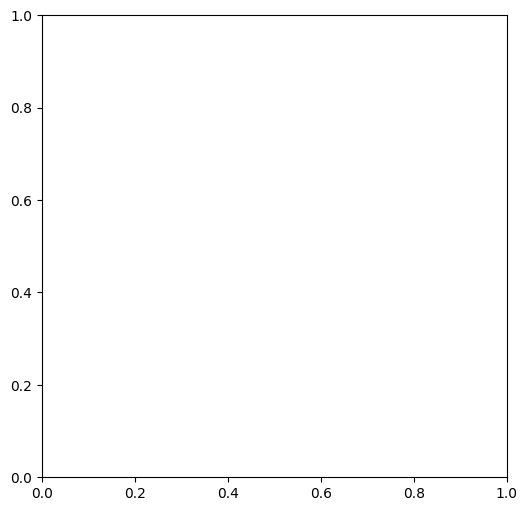

In [ ]:
import numpy as np
from google.colab import autoviz

def scatter_plots(df, colname_pairs, figscale=1, alpha=.8):
  from matplotlib import pyplot as plt
  plt.figure(figsize=(len(colname_pairs) * 6 * figscale, 6 * figscale))
  for plot_i, (x_colname, y_colname) in enumerate(colname_pairs, start=1):
    ax = plt.subplot(1, len(colname_pairs), plot_i)
    df.plot(kind='scatter', x=x_colname, y=y_colname, s=(32 * figscale), alpha=alpha, ax=ax)
    ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = scatter_plots(resources_df, *[[['x', 'y']]], **{})
chart

## Heatmap (2D type x time_of_day)

In [ ]:
import numpy as np
from google.colab import autoviz

def heatmap(df, x_colname, y_colname, figscale=1, mpl_palette_name='viridis'):
  from matplotlib import pyplot as plt
  import seaborn as sns
  import pandas as pd
  plt.subplots(figsize=(8 * figscale, 8 * figscale))
  df_2dhist = pd.DataFrame({
      x_label: grp[y_colname].value_counts()
      for x_label, grp in df.groupby(x_colname)
  })
  sns.heatmap(df_2dhist, cmap=mpl_palette_name)
  plt.xlabel(x_colname)
  plt.ylabel(y_colname)
  return autoviz.MplChart.from_current_mpl_state()

chart = heatmap(resources_df, *['time_of_day', 'resource_type'], **{})
chart

## Type by time of day

In [ ]:
import numpy as np
from google.colab import autoviz

def time_series_multiline(df, timelike_colname, value_colname, series_colname, figscale=1, mpl_palette_name='Dark2'):
  from matplotlib import pyplot as plt
  import seaborn as sns
  figsize = (10 * figscale, 5.2 * figscale)
  palette = list(sns.palettes.mpl_palette(mpl_palette_name))
  def _plot_series(series, series_name, series_index=0):
    if value_colname == 'count()':
      counted = (series[timelike_colname]
                 .value_counts()
                 .reset_index(name='counts')
                 .rename({'index': timelike_colname}, axis=1)
                 .sort_values(timelike_colname, ascending=True))
      xs = counted[timelike_colname]
      ys = counted['counts']
    else:
      xs = series[timelike_colname]
      ys = series[value_colname]
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

  fig, ax = plt.subplots(figsize=figsize, layout='constrained')
  df = df.sort_values(timelike_colname, ascending=True)
  if series_colname:
    for i, (series_name, series) in enumerate(df.groupby(series_colname)):
      _plot_series(series, series_name, i)
    fig.legend(title=series_colname, bbox_to_anchor=(1, 1), loc='upper left')
  else:
    _plot_series(df, '')
  sns.despine(fig=fig, ax=ax)
  plt.xlabel(timelike_colname)
  plt.ylabel(value_colname)
  return autoviz.MplChart.from_current_mpl_state()

chart = time_series_multiline(resources_df, *['time_of_day', 'count()', 'resource_type'], **{})
chart

## Total by type

In [ ]:
import numpy as np
from google.colab import autoviz

def categorical_histogram(df, colname, figscale=1, mpl_palette_name='Dark2'):
  from matplotlib import pyplot as plt
  import seaborn as sns
  df.groupby(colname).size().plot(kind='barh', color=sns.palettes.mpl_palette(mpl_palette_name), figsize=(8*figscale, 4.8*figscale))
  plt.gca().spines[['top', 'right',]].set_visible(False)
  return autoviz.MplChart.from_current_mpl_state()

chart = categorical_histogram(resources_df, *['resource_type'], **{})
chart

## Count by day (by type)

In [ ]:
import numpy as np
from google.colab import autoviz

def time_series_multiline(df, timelike_colname, value_colname, series_colname, figscale=1, mpl_palette_name='Dark2'):
  from matplotlib import pyplot as plt
  import seaborn as sns
  figsize = (10 * figscale, 5.2 * figscale)
  palette = list(sns.palettes.mpl_palette(mpl_palette_name))
  def _plot_series(series, series_name, series_index=0):
    if value_colname == 'count()':
      counted = (series[timelike_colname]
                 .value_counts()
                 .reset_index(name='counts')
                 .rename({'index': timelike_colname}, axis=1)
                 .sort_values(timelike_colname, ascending=True))
      xs = counted[timelike_colname]
      ys = counted['counts']
    else:
      xs = series[timelike_colname]
      ys = series[value_colname]
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

  fig, ax = plt.subplots(figsize=figsize, layout='constrained')
  df = df.sort_values(timelike_colname, ascending=True)
  if series_colname:
    for i, (series_name, series) in enumerate(df.groupby(series_colname)):
      _plot_series(series, series_name, i)
    fig.legend(title=series_colname, bbox_to_anchor=(1, 1), loc='upper left')
  else:
    _plot_series(df, '')
  sns.despine(fig=fig, ax=ax)
  plt.xlabel(timelike_colname)
  plt.ylabel(value_colname)
  return autoviz.MplChart.from_current_mpl_state()

chart = time_series_multiline(resources_df, *['day', 'count()', 'resource_type'], **{})
chart

# Todo


- create plots for other islands
- resource subtype and quality
- define probability adjustments

- creature and faction effects of items
- define player behaviors? (local: pick island, vs global: pick around)

In [3]:
data = """
Glint	Light	Blue	A
Prismaros	Light	Blue	B
Aurora	Light	Blue	C
Celestia	Light	Blue	D
Radiant	Light	Blue	E
Amethyst	Light	Purple	A
Luminara	Light	Purple	B
Iris	Light	Purple	C
Seraphim	Light	Purple	D
Violet	Light	Purple	E
Pyroshimmer	Light	Red	A
Blaze	Light	Red	B
Radiance	Light	Red	C
Ignatia	Light	Red	D
Phoenix	Light	Red	E
Viridium	Light	Green	A
Meadowlark	Light	Green	B
Lumigrove	Light	Green	C
Verdant	Light	Green	D
Zephyr	Light	Green	E
Solara	Light	Yellow	A
Lumos	Light	Yellow	B
Aurelia	Light	Yellow	C
Luminary	Light	Yellow	D
Radiantwing	Light	Yellow	E
Umbra	Shadow	Blue	A
Shade	Shadow	Blue	B
Duskray	Shadow	Blue	C
Twilight	Shadow	Blue	D
Nyx	Shadow	Blue	E
Obsidian	Shadow	Purple	A
Shadowstrike	Shadow	Purple	B
Eclipse	Shadow	Purple	C
Nocturna	Shadow	Purple	D
Nox	Shadow	Purple	E
Pyroshadow	Shadow	Red	A
Ember	Shadow	Red	B
Shadowfire	Shadow	Red	C
Inferno	Shadow	Red	D
Ashen	Shadow	Red	E
Verdigris	Shadow	Green	A
Murk	Shadow	Green	B
Shadowthorn	Shadow	Green	C
Mossbane	Shadow	Green	D
Shadowleaf	Shadow	Green	E
Umbertide	Shadow	Yellow	A
Gloomsong	Shadow	Yellow	B
Shadowflare	Shadow	Yellow	C
Twilightspire	Shadow	Yellow	D
Nightshade	Shadow	Yellow	E
Flora	Growth	Blue	A
Lush	Growth	Blue	B
Sylvan	Growth	Blue	C
Meadow	Growth	Blue	D
Zephyrus	Growth	Blue	E
Blossom	Growth	Purple	A
Petal	Growth	Purple	B
Thorn	Growth	Purple	C
Rose	Growth	Purple	D
Fern	Growth	Purple	E
Mosswhisper	Growth	Red	A
Bramble	Growth	Red	B
Sunleaf	Growth	Red	C
Emberbloom	Growth	Red	D
Chlorophyll	Growth	Red	E
Viridius	Growth	Green	A
Willow	Growth	Green	B
Oakheart	Growth	Green	C
Ivy	Growth	Green	D
Thicket	Growth	Green	E
Solstice	Growth	Yellow	A
Gleam	Growth	Yellow	B
Radiant Blossom	Growth	Yellow	C
Vivaro	Growth	Yellow	D
Evergreen	Growth	Yellow	E
Granite	Stability	Blue	A
Steadfast	Stability	Blue	B
Vanguard	Stability	Blue	C
Shieldstone	Stability	Blue	D
Ironclad	Stability	Blue	E
Ash	Stability	Purple	A
Stonewall	Stability	Purple	B
Firmament	Stability	Purple	C
Grit	Stability	Purple	D
Solidarity	Stability	Purple	E
Ambrose	Stability	Red	A
Hearth	Stability	Red	B
Ironheart	Stability	Red	C
Resolute	Stability	Red	D
Valiant	Stability	Red	E
Verdantia	Stability	Green	A
Stalwart	Stability	Green	B
Strongroot	Stability	Green	C
Solidrock	Stability	Green	D
Endurance	Stability	Green	E
Aurum	Stability	Yellow	A
Guardian	Stability	Yellow	B
Ironcliff	Stability	Yellow	C
Steelsong	Stability	Yellow	D
Lastingheart	Stability	Yellow	E
"""

creatures_dict = {}
lines = data.strip().split("\n")
for line in lines:
    name, faction, color, attribute = line.split("\t")
    creature_json = {
        "creature_name": name,
        "creature_color": color,
        "creature_attribute": attribute
    }

    if faction not in creatures_dict:
        creatures_dict[faction] = []
    creatures_dict[faction].append(creature_json)

CREATURES = creatures_dict

# To pretty print the JSON with each creature on a single line:
import json
print("{")
for faction, creatures in CREATURES.items():
    creatures_str = ", ".join(json.dumps(creature) for creature in creatures)
    print(f'"{faction}": [{creatures_str}],')
print("}")

{
"Light": [{"creature_name": "Glint", "creature_color": "Blue", "creature_attribute": "A"}, {"creature_name": "Prismaros", "creature_color": "Blue", "creature_attribute": "B"}, {"creature_name": "Aurora", "creature_color": "Blue", "creature_attribute": "C"}, {"creature_name": "Celestia", "creature_color": "Blue", "creature_attribute": "D"}, {"creature_name": "Radiant", "creature_color": "Blue", "creature_attribute": "E"}, {"creature_name": "Amethyst", "creature_color": "Purple", "creature_attribute": "A"}, {"creature_name": "Luminara", "creature_color": "Purple", "creature_attribute": "B"}, {"creature_name": "Iris", "creature_color": "Purple", "creature_attribute": "C"}, {"creature_name": "Seraphim", "creature_color": "Purple", "creature_attribute": "D"}, {"creature_name": "Violet", "creature_color": "Purple", "creature_attribute": "E"}, {"creature_name": "Pyroshimmer", "creature_color": "Red", "creature_attribute": "A"}, {"creature_name": "Blaze", "creature_color": "Red", "creature_a